# Data Preprocessing

In [ ]:
# Remember: library imports are ALWAYS at the top of the script, no exceptions!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from math import ceil

sns.set()

In [2]:
## Un-comment these if you want to use ydata_profiling

# !pip install -U ydata-profiling
# from ydata_profiling import ProfileReport


## Context
The data we will be using through the pratical classes comes from a small relational database whose schema can be seen below:
![Schema](https://raw.githubusercontent.com/fpontejos/DM1_2324/main/figures/schema.png "Relation database schema")

## Reading the Data

In [ ]:
## Allow Colab to see Google Drive files

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## Load csv file into a dataframe
## Paste the path here
data_path = "/content/drive/MyDrive/Colab Data/datamining.csv"

df = pd.read_csv(data_path)

In [3]:
## Load csv file into a dataframe
## Alternative location of the csv file

## data_path = "https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/datamining.csv"

## df = pd.read_csv(data_path)

### Make a copy of your original dataset

why?

In [4]:
df_original = df.copy()

## Metadata
- *id* - The unique identifier of the customer
- *age* - The year of birht of the customer
- *income* - The income of the customer
- *frq* - Frequency: number of purchases made by the customer
- *rcn* - Recency: number of days since last customer purchase
- *mnt* - Monetary: amount of € spent by the customer in purchases
- *clothes* - Number of clothes items purchased by the customer
- *kitchen* - Number of kitchen items purchased by the customer
- *small_appliances* - Number of small_appliances items purchased by the customer
- *toys* - Number of toys items purchased by the customer
- *house_keeping* - Number of house_keeping items purchased by the customer
- *dependents* - Binary. Whether or not the customer has dependents
- *per_net_purchase* - Percentage of purchases made online
- *education* - Education level of the customer
- *status* - Marital status of the customer
- *gender* - Gender of the customer
- *description* - Last customer's recommendation description

## Problems:
- Duplicates?
- Data types?
- Missing values?
- Strange values?
- Descriptive statistics?

### Take a closer look and point out possible problems:

(hint: a missing values in pandas is represented with a NaN value)

In [5]:
df.dtypes

,0
Unnamed: 0,int64
age,int64
income,float64
frq,int64
rcn,int64
mnt,int64
clothes,int64
kitchen,int64
small_appliances,int64
toys,int64


In [6]:
# Check descriptive statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,8998.0,NaN,NaN,NaN,4498.5,2597.643195,0.0,2249.25,4498.5,6747.75,8997.0
age,8998.0,NaN,NaN,NaN,1966.05968,17.296552,1936.0,1951.0,1966.0,1981.0,1996.0
income,8952.0,NaN,NaN,NaN,69963.550827,27591.556226,10000.0,47741.0,70030.5,92218.0,140628.0
frq,8998.0,NaN,NaN,NaN,19.848077,10.903435,3.0,10.0,17.0,28.0,59.0
rcn,8998.0,NaN,NaN,NaN,62.469771,69.761802,0.0,26.0,53.0,79.0,549.0
mnt,8998.0,NaN,NaN,NaN,622.162814,646.768205,6.0,63.0,383.0,1076.0,3052.0
clothes,8998.0,NaN,NaN,NaN,50.446655,23.422249,1.0,33.0,51.0,69.0,99.0
kitchen,8998.0,NaN,NaN,NaN,7.039675,7.848139,0.0,2.0,4.0,10.0,75.0
small_appliances,8998.0,NaN,NaN,NaN,28.524116,12.586437,1.0,19.0,28.0,37.0,74.0
toys,8998.0,NaN,NaN,NaN,7.036897,7.924422,0.0,2.0,4.0,10.0,62.0


In [7]:
df.head()

,Unnamed: 0,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
0,0,1946,90782.0,33,66,1402,37,5,44,10,3,0.0,19,M,Graduation,Together,Take my money!!
1,1,1936,113023.0,32,6,1537,55,1,38,4,2,0.0,9,F,PhD,Divorced,Take my money!!
2,2,1990,28344.0,11,69,44,32,19,24,1,24,1.0,59,M,Graduation,Married,Kind of OK
3,3,1955,93571.0,26,10,888,60,10,19,6,5,1.0,35,F,Master,NaN,OK nice!
4,4,1955,91852.0,31,26,1138,59,5,28,4,4,1.0,34,F,Graduation,Together,Take my money!!


In [8]:
# Sometimes it is not obvious that a value is missing
# For example if the value is an empty string

# replace "" by nans
df.replace("", np.nan, inplace=True)

In [9]:
df["dependents"] = df["dependents"].astype("boolean")

In [10]:
# check dataset data types again
df.dtypes

,0
Unnamed: 0,int64
age,int64
income,float64
frq,int64
rcn,int64
mnt,int64
clothes,int64
kitchen,int64
small_appliances,int64
toys,int64


In [11]:
# check descriptive statistics again
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,8998.0,NaN,NaN,NaN,4498.5,2597.643195,0.0,2249.25,4498.5,6747.75,8997.0
age,8998.0,NaN,NaN,NaN,1966.05968,17.296552,1936.0,1951.0,1966.0,1981.0,1996.0
income,8952.0,NaN,NaN,NaN,69963.550827,27591.556226,10000.0,47741.0,70030.5,92218.0,140628.0
frq,8998.0,NaN,NaN,NaN,19.848077,10.903435,3.0,10.0,17.0,28.0,59.0
rcn,8998.0,NaN,NaN,NaN,62.469771,69.761802,0.0,26.0,53.0,79.0,549.0
mnt,8998.0,NaN,NaN,NaN,622.162814,646.768205,6.0,63.0,383.0,1076.0,3052.0
clothes,8998.0,NaN,NaN,NaN,50.446655,23.422249,1.0,33.0,51.0,69.0,99.0
kitchen,8998.0,NaN,NaN,NaN,7.039675,7.848139,0.0,2.0,4.0,10.0,75.0
small_appliances,8998.0,NaN,NaN,NaN,28.524116,12.586437,1.0,19.0,28.0,37.0,74.0
toys,8998.0,NaN,NaN,NaN,7.036897,7.924422,0.0,2.0,4.0,10.0,62.0


In [12]:
# Define metric and non-metric features. Why?
non_metric_features = ["education", "status", "gender", "dependents", "description"]

## This is saying that the metric features are all the other features that are not non-metric
## Need to be careful in case not all columns are to be used as features

# metric_features = df.columns.drop(non_metric_features).to_list()

## Or you can also specify manually
metric_features = ['age',
 'income',
 'frq',
 'rcn',
 'mnt',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase']

### Fill missing values (Data imputation)

How can we fill missing values?


#### Using measures of central tendency

In [13]:
# Creating a copy to apply central tendency measures imputation
df_central = df.copy()

In [14]:
# count of missing values
df_central.isna().sum()

,0
Unnamed: 0,0
age,0
income,46
frq,0
rcn,0
mnt,0
clothes,0
kitchen,0
small_appliances,0
toys,0


In [15]:
medians = df_central[metric_features].median()
medians

,0
age,1966.0
income,70030.5
frq,17.0
rcn,53.0
mnt,383.0
clothes,51.0
kitchen,4.0
small_appliances,28.0
toys,4.0
house_keeping,4.0


In [16]:
modes = df_central[non_metric_features].mode().loc[0]
modes

,0
education,Graduation
status,Married
gender,M
dependents,True
description,OK nice!


In [17]:
## Fill NaNs using medians and modes

df_central.fillna(medians, inplace=True)
df_central.fillna(modes, inplace=True)

In [18]:
df_central.isna().sum()  # checking how many NaNs we still have

,0
Unnamed: 0,0
age,0
income,0
frq,0
rcn,0
mnt,0
clothes,0
kitchen,0
small_appliances,0
toys,0


#### Using Nearest Neighbor imputation

In [19]:
# Creating new df copy to explore neighbordhood imputation
df_neighbors = df.copy()

In [20]:
# Seeing rows with NaNs
nans_index = df_neighbors.isna().any(axis=1)
df_neighbors[nans_index]


,Unnamed: 0,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
3,3,1955,93571.0,26,10,888,60,10,19,6,5,True,35,F,Master,NaN,OK nice!
61,61,1968,NaN,14,90,184,95,1,3,1,0,True,59,F,2nd Cycle,Married,Meh...
67,67,1981,60457.0,9,73,63,37,2,51,6,3,<NA>,57,M,PhD,Married,Meh...
70,70,1944,116259.0,28,35,1279,17,6,54,3,20,False,11,M,Graduation,NaN,OK nice!
73,73,1967,75274.0,16,67,263,88,3,6,1,2,<NA>,66,M,Graduation,Single,Kind of OK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8932,8932,1959,NaN,20,71,716,67,5,25,3,1,False,27,M,Graduation,Married,Meh...
8942,8942,1950,92746.0,34,98,1399,50,5,36,5,4,<NA>,28,M,Master,Married,Take my money!!
8964,8964,1978,44661.0,6,49,33,18,18,35,16,13,True,42,M,1st Cycle,NaN,OK nice!
8972,8972,1976,NaN,17,9,254,70,1,28,1,1,True,59,M,Graduation,Divorced,Meh...


In [21]:
# Use KNNImputer - only works for numerical variables
imputer = KNNImputer(n_neighbors=5, weights="uniform")
df_neighbors[metric_features] = imputer.fit_transform(df_neighbors[metric_features])

In [22]:
# See rows with NaNs imputed
df_neighbors.loc[nans_index, metric_features]

,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase
3,1955.0,93571.0,26.0,10.0,888.0,60.0,10.0,19.0,6.0,5.0,35.0
61,1968.0,63143.0,14.0,90.0,184.0,95.0,1.0,3.0,1.0,0.0,59.0
67,1981.0,60457.0,9.0,73.0,63.0,37.0,2.0,51.0,6.0,3.0,57.0
70,1944.0,116259.0,28.0,35.0,1279.0,17.0,6.0,54.0,3.0,20.0,11.0
73,1967.0,75274.0,16.0,67.0,263.0,88.0,3.0,6.0,1.0,2.0,66.0
...,...,...,...,...,...,...,...,...,...,...,...
8932,1959.0,85643.4,20.0,71.0,716.0,67.0,5.0,25.0,3.0,1.0,27.0
8942,1950.0,92746.0,34.0,98.0,1399.0,50.0,5.0,36.0,5.0,4.0,28.0
8964,1978.0,44661.0,6.0,49.0,33.0,18.0,18.0,35.0,16.0,13.0,42.0
8972,1976.0,63932.4,17.0,9.0,254.0,70.0,1.0,28.0,1.0,1.0,59.0


In [23]:
# let's keep the central imputation
df = df_central.copy()

### Outlier removal

Why do we need to remove outliers? Which methods can we use?


Let's start by "manually" filtering the dataset's outliers

In [24]:
def remove_outliers(df, filters):

  df_2 = df[filters]
  print('Percentage of data kept after removing outliers:', 100*(np.round(df_2.shape[0] / df.shape[0], 4)))

  return df_2



In [25]:
# This may vary from session to session, and is prone to varying interpretations.
# A simple example is provided below:

manual_filters = (
    (df['house_keeping']<=50)
    &
    (df['kitchen']<=40)
    &
    (df['toys']<=35)
    &
    (df['education']!='OldSchool')
)

df_1 = remove_outliers(df, manual_filters)

Percentage of data kept after removing outliers: 97.99


#### Outlier removal using only the IQR method

Why should you use/not use this method?

In [26]:
## Remember our boxplots from previous practical session?

def plot_multiple_boxplots(data, feats, title="Numeric Variables' Box Plots", figsize=(18, 8)):

    # Prepare figure. Create individual axes where each histogram will be placed
    fig, axes = plt.subplots(2, ceil(len(feats) / 2), figsize=figsize)

    # Plot data
    # Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
    for ax, feat in zip(axes.flatten(), feats): # Notice the zip() function and flatten() method
      sns.boxplot(x=data[feat], ax=ax)
      ax.set_title(feat)
      ax.set_xlabel("")

    # Layout
    # Add a centered title to the figure:
    plt.suptitle(title)

    plt.show()

    return



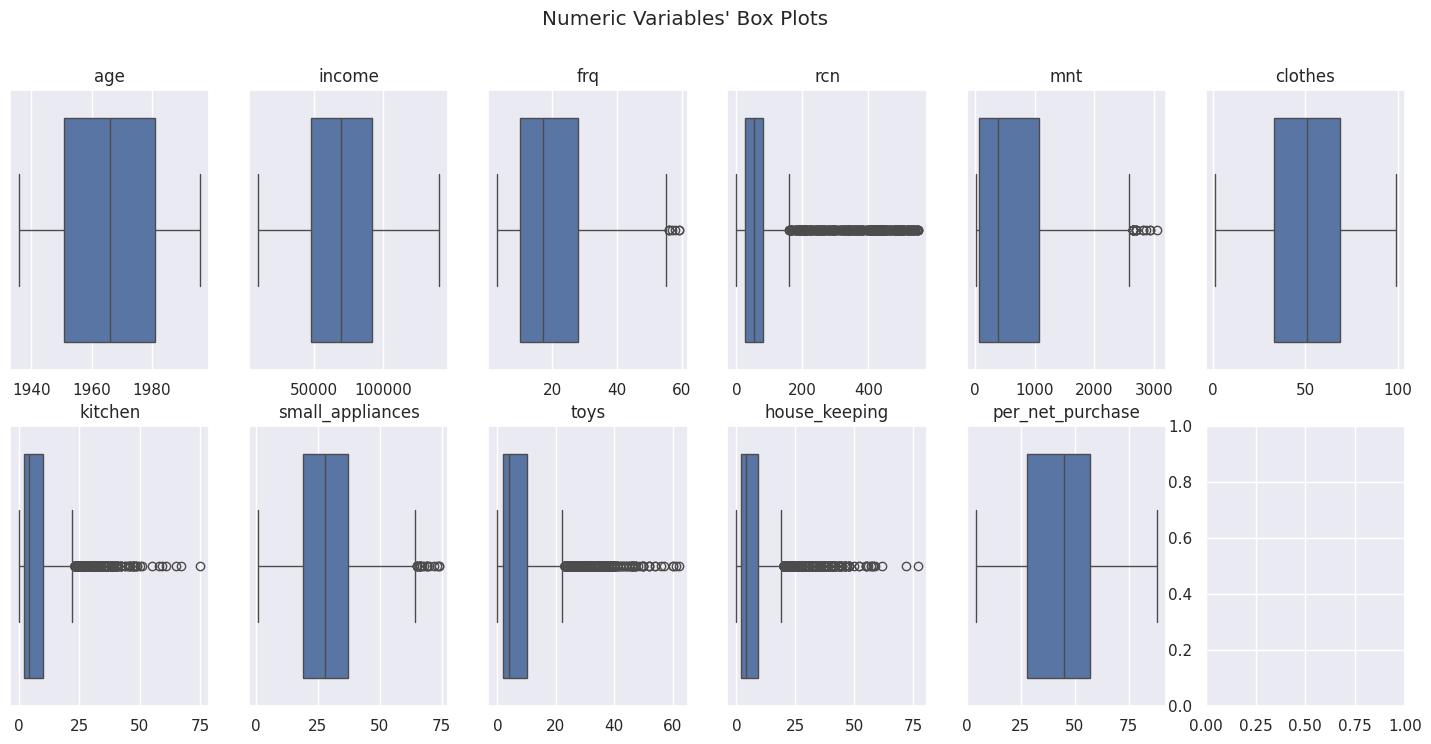

In [27]:
# All Numeric Variables' Histograms in one figure
sns.set()

plot_multiple_boxplots(df, metric_features)


In [28]:
def get_iqr_filters(df, feats, lower_q=.25, upper_q=.75):
  q25 = df[feats].quantile(lower_q)
  q75 = df[feats].quantile(upper_q)
  iqr = (q75 - q25)

  upper_lim = q75 + 1.5 * iqr
  lower_lim = q25 - 1.5 * iqr

  iqr_filters = []
  for metric in feats:
      llim = lower_lim[metric]
      ulim = upper_lim[metric]
      iqr_filters.append(df[metric].between(llim, ulim, inclusive='both'))

  filters = pd.Series(np.all(iqr_filters, 0))


  return filters



In [29]:
iqr_filters = get_iqr_filters(df, metric_features)

df_iqr = remove_outliers(df, iqr_filters)

Percentage of data kept after removing outliers: 82.42


What do you think about this percentage?

### Combining different outlier methods

More robust/ consistent outlier detection method:

In [30]:
df_3 = df[(manual_filters | iqr_filters)]
print('Percentage of data kept after removing outliers:', 100*(np.round(df_3.shape[0] / df_original.shape[0], 4)))

Percentage of data kept after removing outliers: 98.19


In [31]:
# Get the manual filtering version
df = df_1.copy()

#### Remember the "rcn" histogram?

<Axes: >

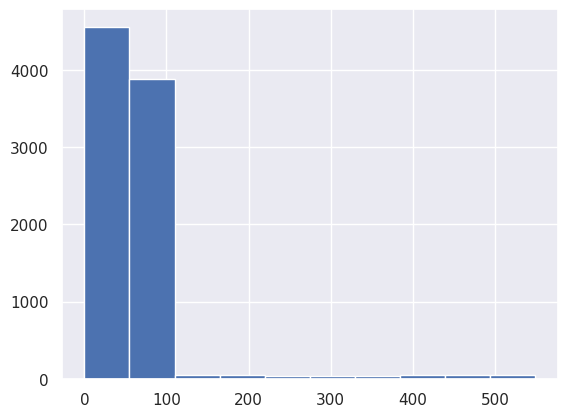

In [32]:
df['rcn'].hist()

In [33]:
# How can we avoid having as many extreme values in 'rcn'?
print((df['rcn']>100).value_counts())

rcn_t = df['rcn'].copy()
rcn_t.loc[rcn_t>100] = 100

df['rcn'] = rcn_t

rcn
False    8437
True      380
Name: count, dtype: int64


#### What about non-metric features?

![](https://raw.githubusercontent.com/fpontejos/DM1_2324/main/figures/exp_analysis/categorical_variables_frequecies.png)

In [34]:
# Let's also remove status=Whatever
df.loc[df['status'] == 'Whatever', 'status'] = df['status'].mode()[0]


### Feature Engineering and Feature Selection

A reminder of our metadata:
- *id* - The unique identifier of the customer
- *age* - The year of birht of the customer
- *income* - The income of the customer
- *frq* - Frequency: number of purchases made by the customer
- *rcn* - Recency: number of days since last customer purchase
- *mnt* - Monetary: amount of € spent by the customer in purchases
- *clothes* - Number of clothes items purchased by the customer
- *kitchen* - Number of kitchen items purchased by the customer
- *small_appliances* - Number of small_appliances items purchased by the customer
- *toys* - Number of toys items purchased by the customer
- *house_keeping* - Number of house_keeping items purchased by the customer
- *dependents* - Binary. Whether or not the customer has dependents
- *per_net_purchase* - Percentage of purchases made online
- *education* - Education level of the customer
- *status* - Marital status of the customer
- *gender* - Gender of the customer
- *description* - Last customer's recommendation description

In [35]:
df['birth_year'] = df['age']
df['age'] = datetime.now().year - df['birth_year']

df['spent_online'] = (df['per_net_purchase'] / 100) * df['mnt']

Ratios (divide)

Multiply

Add things


### Variable selection: Redundancy VS Relevancy

### Redundancy
We already saw our original correlation matrix:
![Correlation Matrix](https://raw.githubusercontent.com/fpontejos/DM1_2324/main/figures/exp_analysis/correlation_matrix.png)

In [36]:
# Select variables according to their correlations
# df.drop(columns=['birth_year', 'age', 'mnt'], inplace=True)
unused_feats =[]

In [37]:
## Reminder of our metric features
metric_features

['age',
 'income',
 'frq',
 'rcn',
 'mnt',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase']

In [38]:
# Updating metric_features
metric_features.append("spent_online")
metric_features.remove("mnt")
metric_features.remove("age")

In [39]:
metric_features

['income',
 'frq',
 'rcn',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase',
 'spent_online']

### Relevancy
Selecting variables based on the relevancy of each one to the task. Example: remove uncorrelated variables with the target, stepwise regression, use variables for product clustering, use variables for socio-demographic clustering, ...

Variables that aren't correlated with any other variable are often also not relevant. In this case we will not focus on this a lot since we don't have a defined task yet.

### Data Normalization

#### MinMax Scaling

In [40]:
df_minmax = df.copy()

In [42]:
df_minmax.shape

(8817, 19)

In [43]:
# Use MinMaxScaler to scale the data
scaler = MinMaxScaler()
scaled_feat = scaler.fit_transform(df_minmax[metric_features])
scaled_feat

array([[0.61841259, 0.53571429, 0.66      , ..., 0.06      , 0.17857143,
        0.1865215 ],
       [0.78867471, 0.51785714, 0.06      , ..., 0.04      , 0.05952381,
        0.0959314 ],
       [0.14042931, 0.14285714, 0.69      , ..., 0.48      , 0.6547619 ,
        0.01643427],
       ...,
       [0.36838197, 0.16071429, 0.06      , ..., 0.12      , 0.79761905,
        0.02870868],
       [0.33906972, 0.46428571, 0.72      , ..., 0.22      , 0.32142857,
        0.21979328],
       [0.88772698, 0.625     , 0.75      , ..., 0.12      , 0.48809524,
        0.52908717]])

In [44]:
df_minmax[metric_features] = scaled_feat
df_minmax.head()

,Unnamed: 0,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description,birth_year,spent_online
0,0,79,0.618413,0.535714,0.66,1402,0.367347,0.125,0.589041,0.285714,0.06,False,0.178571,M,Graduation,Together,Take my money!!,1946,0.186521
1,1,89,0.788675,0.517857,0.06,1537,0.551020,0.025,0.506849,0.114286,0.04,False,0.059524,F,PhD,Divorced,Take my money!!,1936,0.095931
2,2,35,0.140429,0.142857,0.69,44,0.316327,0.475,0.315068,0.028571,0.48,True,0.654762,M,Graduation,Married,Kind of OK,1990,0.016434
3,3,70,0.639763,0.410714,0.10,888,0.602041,0.250,0.246575,0.171429,0.10,True,0.369048,F,Master,Married,OK nice!,1955,0.217947
4,4,70,0.626604,0.500000,0.26,1138,0.591837,0.125,0.369863,0.114286,0.08,True,0.357143,F,Graduation,Together,Take my money!!,1955,0.271799


In [45]:
# Checking max and min of minmaxed variables
df_minmax[metric_features].describe().round(2)

,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
count,8817.00,8817.00,8817.00,8817.00,8817.00,8817.00,8817.00,8817.00,8817.00,8817.00
mean,0.46,0.30,0.52,0.51,0.17,0.38,0.19,0.14,0.46,0.12
std,0.21,0.19,0.30,0.23,0.18,0.17,0.20,0.15,0.22,0.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.30,0.12,0.26,0.34,0.05,0.25,0.06,0.04,0.27,0.02
50%,0.46,0.27,0.53,0.52,0.10,0.37,0.11,0.08,0.49,0.10
75%,0.63,0.45,0.78,0.70,0.22,0.49,0.26,0.18,0.63,0.19
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


#### Standard Scaling

In [46]:
df_standard = df.copy()

In [47]:
scaler = StandardScaler()
scaled_feat = scaler.fit_transform(df_standard[metric_features])
scaled_feat

array([[ 0.74316169,  1.1916046 ,  0.45781896, ..., -0.49927359,
        -1.25755953,  0.52205471],
       [ 1.55948802,  1.10001063, -1.53572277, ..., -0.63190677,
        -1.79864925, -0.23757758],
       [-1.5485421 , -0.82346271,  0.55749604, ...,  2.28602317,
         0.90679936, -0.90419125],
       ...,
       [-0.4556169 , -0.73186874, -1.53572277, ..., -0.10137405,
         1.55610702, -0.80126567],
       [-0.59615525,  0.82522873,  0.65717313, ...,  0.56179185,
        -0.60825186,  0.80105125],
       [ 2.03439682,  1.64957444,  0.75685022, ..., -0.10137405,
         0.14927375,  3.39459784]])

In [48]:
df_standard[metric_features] = scaled_feat
df_standard.head()

,Unnamed: 0,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description,birth_year,spent_online
0,0,79,0.743162,1.191605,0.457819,1402,-0.617023,-0.243065,1.216847,0.495837,-0.499274,False,-1.257560,M,Graduation,Together,Take my money!!,1946,0.522055
1,1,89,1.559488,1.100011,-1.535723,1537,0.166160,-0.790228,0.740464,-0.374374,-0.631907,False,-1.798649,F,PhD,Divorced,Take my money!!,1936,-0.237578
2,2,35,-1.548542,-0.823463,0.557496,44,-0.834573,1.672006,-0.371096,-0.809480,2.286023,True,0.906799,M,Graduation,Married,Kind of OK,1990,-0.904191
3,3,70,0.845528,0.550447,-1.402820,888,0.383710,0.440889,-0.768082,-0.084304,-0.234007,True,-0.391816,F,Master,Married,OK nice!,1955,0.785568
4,4,70,0.782435,1.008417,-0.871209,1138,0.340200,-0.243065,-0.053508,-0.374374,-0.366640,True,-0.445925,F,Graduation,Together,Take my money!!,1955,1.237135


In [49]:
# Checking mean and variance of standardized variables
df_standard[metric_features].describe().round(2)

,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
count,8817.00,8817.00,8817.00,8817.00,8817.00,8817.00,8817.00,8817.00,8817.00,8817.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.22,-1.56,-1.74,-2.18,-0.93,-2.20,-0.95,-0.90,-2.07,-1.04
25%,-0.80,-0.92,-0.87,-0.75,-0.65,-0.77,-0.66,-0.63,-0.82,-0.85
50%,-0.01,-0.18,0.03,0.04,-0.38,-0.05,-0.37,-0.37,0.15,-0.23
75%,0.80,0.73,0.86,0.82,0.30,0.66,0.35,0.30,0.80,0.51
max,2.57,3.57,1.59,2.08,4.54,3.60,4.12,5.73,2.48,7.34


In [50]:
df = df_standard.copy()

### One-hot encoding

Why do we need to do this?

In [51]:
df_ohc = df.copy()

In [52]:
def get_ohc_df(df, feats):
  # Use OneHotEncoder to encode the categorical features.
  # Get feature names and create a DataFrame
  # with the one-hot encoded categorical features (pass feature names)

  ohc = OneHotEncoder(sparse_output=False, drop="first")
  ohc_feat = ohc.fit_transform(df[feats])
  ohc_feat_names = ohc.get_feature_names_out()
  ohc_df = pd.DataFrame(ohc_feat, index=df.index, columns=ohc_feat_names)

  # Reassigning df to contain ohc variables
  df_ohc = pd.concat([df, ohc_df], axis=1)

  return df_ohc, ohc

df_ohc, ohc = get_ohc_df(df, non_metric_features)


In [53]:
df_ohc.shape

(8817, 33)

In [54]:
ohc_feats = ohc.get_feature_names_out().tolist()
ohc_feats

['education_2nd Cycle',
 'education_Graduation',
 'education_Master',
 'education_PhD',
 'status_Married',
 'status_Single',
 'status_Together',
 'status_Widow',
 'gender_M',
 'dependents_1.0',
 'description_Kind of OK',
 'description_Meh...',
 'description_OK nice!',
 'description_Take my money!!']

In [55]:
df_ohc.columns

Index(['Unnamed: 0', 'age', 'income', 'frq', 'rcn', 'mnt', 'clothes',
       'kitchen', 'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description',
       'birth_year', 'spent_online', 'education_2nd Cycle',
       'education_Graduation', 'education_Master', 'education_PhD',
       'status_Married', 'status_Single', 'status_Together', 'status_Widow',
       'gender_M', 'dependents_1.0', 'description_Kind of OK',
       'description_Meh...', 'description_OK nice!',
       'description_Take my money!!'],
      dtype='object')

In [56]:
df = df_ohc.copy()

## Next: Clustering Algorithms

### Questions?

## [OPTIONAL] Exercise

To practice your data preprocessing skills, you can do the same exercises on a different dataset.


The Spaceship Titanic Dataset has been loaded for you in the cells below. You can find more information about this dataset from the Kaggle link.


Using this notebook as a guide, try to answer the questions that follow.


---

Addison Howard, Ashley Chow, Ryan Holbrook. (2022). Spaceship Titanic. Kaggle. https://kaggle.com/competitions/spaceship-titanic


In [ ]:
titanic_df = pd.read_csv("https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/spaceship_titanic_dataset.csv")


In [ ]:
## Are all the features useful? It might be helpful to read the dataset description on Kaggle.
## Keep only the useful features

titanic_metric_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
titanic_non_metric_features = ['HomePlanet', 'CryoSleep', 'Destination','VIP', 'Transported']


In [ ]:
## Do you have any missing values?
titanic_df.isna().sum()


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [ ]:
## Does it make sense to fill missing values for the Name feature?
## What about Cabin?

titanic_df['Name'].replace(np.nan, "NO_NAME", inplace=True)
titanic_df['Cabin'].replace(np.nan, "NO_CABIN", inplace=True)

titanic_df.isna().sum()


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin             0
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name              0
Transported       0
dtype: int64

In [ ]:
## Replace missing values using one of the methods shown previously
titanic_central = titanic_df.copy()

titanic_medians = titanic_central[titanic_metric_features].median()

titanic_medians

Age             27.0
RoomService      0.0
FoodCourt        0.0
ShoppingMall     0.0
Spa              0.0
VRDeck           0.0
dtype: float64

In [ ]:
titanic_modes = titanic_central[titanic_non_metric_features].mode().loc[0]
titanic_modes

HomePlanet           Earth
CryoSleep            False
Destination    TRAPPIST-1e
VIP                  False
Transported           True
Name: 0, dtype: object

In [ ]:
titanic_central.fillna(titanic_medians, inplace=True)
titanic_central.fillna(titanic_modes, inplace=True)

In [ ]:
# Seeing rows with NaNs
titanic_nn = titanic_df.copy()

titanic_nans_index = titanic_nn.isna().any(axis=1)
titanic_nn[titanic_nans_index]



,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
10,0008_02,Europa,True,B/1/P,TRAPPIST-1e,34.0,False,0.0,0.0,NaN,0.0,0.0,Altardr Flatic,True
16,0014_01,Mars,False,F/3/P,55 Cancri e,27.0,False,1286.0,122.0,NaN,0.0,0.0,Flats Eccle,False
23,0020_03,Earth,True,E/0/S,55 Cancri e,29.0,False,0.0,0.0,NaN,0.0,0.0,Mollen Mcfaddennon,False
25,0020_05,Earth,True,E/0/S,PSO J318.5-22,1.0,False,NaN,0.0,0.0,0.0,0.0,Mael Brantuarez,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8667,9250_01,Europa,False,E/597/P,TRAPPIST-1e,29.0,False,0.0,2972.0,NaN,28.0,188.0,Chain Reedectied,True
8674,9257_01,NaN,False,F/1892/P,TRAPPIST-1e,13.0,False,39.0,0.0,1085.0,24.0,0.0,Ties Apple,False
8675,9259_01,Earth,NaN,F/1893/P,TRAPPIST-1e,44.0,False,1030.0,1015.0,0.0,11.0,NaN,Annah Gilleyons,True
8684,9274_01,NaN,True,G/1508/P,TRAPPIST-1e,23.0,False,0.0,0.0,0.0,0.0,0.0,Chelsa Bullisey,True


In [ ]:
# Use KNNImputer - only works for numerical variables

t_imputer = KNNImputer(n_neighbors=5, weights="uniform")
titanic_nn[titanic_metric_features] = t_imputer.fit_transform(titanic_nn[titanic_metric_features])

titanic_nn.fillna(titanic_modes, inplace=True)

titanic_nn[titanic_nans_index]



,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,0.0,Candra Jacostaffey,True
10,0008_02,Europa,True,B/1/P,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Altardr Flatic,True
16,0014_01,Mars,False,F/3/P,55 Cancri e,27.0,False,1286.0,122.0,256.2,0.0,0.0,Flats Eccle,False
23,0020_03,Earth,True,E/0/S,55 Cancri e,29.0,False,0.0,0.0,0.0,0.0,0.0,Mollen Mcfaddennon,False
25,0020_05,Earth,True,E/0/S,PSO J318.5-22,1.0,False,0.0,0.0,0.0,0.0,0.0,Mael Brantuarez,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8667,9250_01,Europa,False,E/597/P,TRAPPIST-1e,29.0,False,0.0,2972.0,153.6,28.0,188.0,Chain Reedectied,True
8674,9257_01,Earth,False,F/1892/P,TRAPPIST-1e,13.0,False,39.0,0.0,1085.0,24.0,0.0,Ties Apple,False
8675,9259_01,Earth,False,F/1893/P,TRAPPIST-1e,44.0,False,1030.0,1015.0,0.0,11.0,4.0,Annah Gilleyons,True
8684,9274_01,Earth,True,G/1508/P,TRAPPIST-1e,23.0,False,0.0,0.0,0.0,0.0,0.0,Chelsa Bullisey,True


In [ ]:
## Bonus: How to quickly check the difference between results of NN and central imputation?

print(titanic_nn.loc[titanic_nans_index, titanic_metric_features].mean())
print(titanic_central.loc[titanic_nans_index, titanic_metric_features].mean())


Age              28.781130
RoomService     215.558531
FoodCourt       345.171751
ShoppingMall    144.916723
Spa             268.431073
VRDeck          293.089266
dtype: float64
Age              28.393785
RoomService     196.266667
FoodCourt       323.277401
ShoppingMall    131.414689
Spa             251.410169
VRDeck          276.724294
dtype: float64


In [ ]:
## Keep one
titanic_df = titanic_nn.copy()

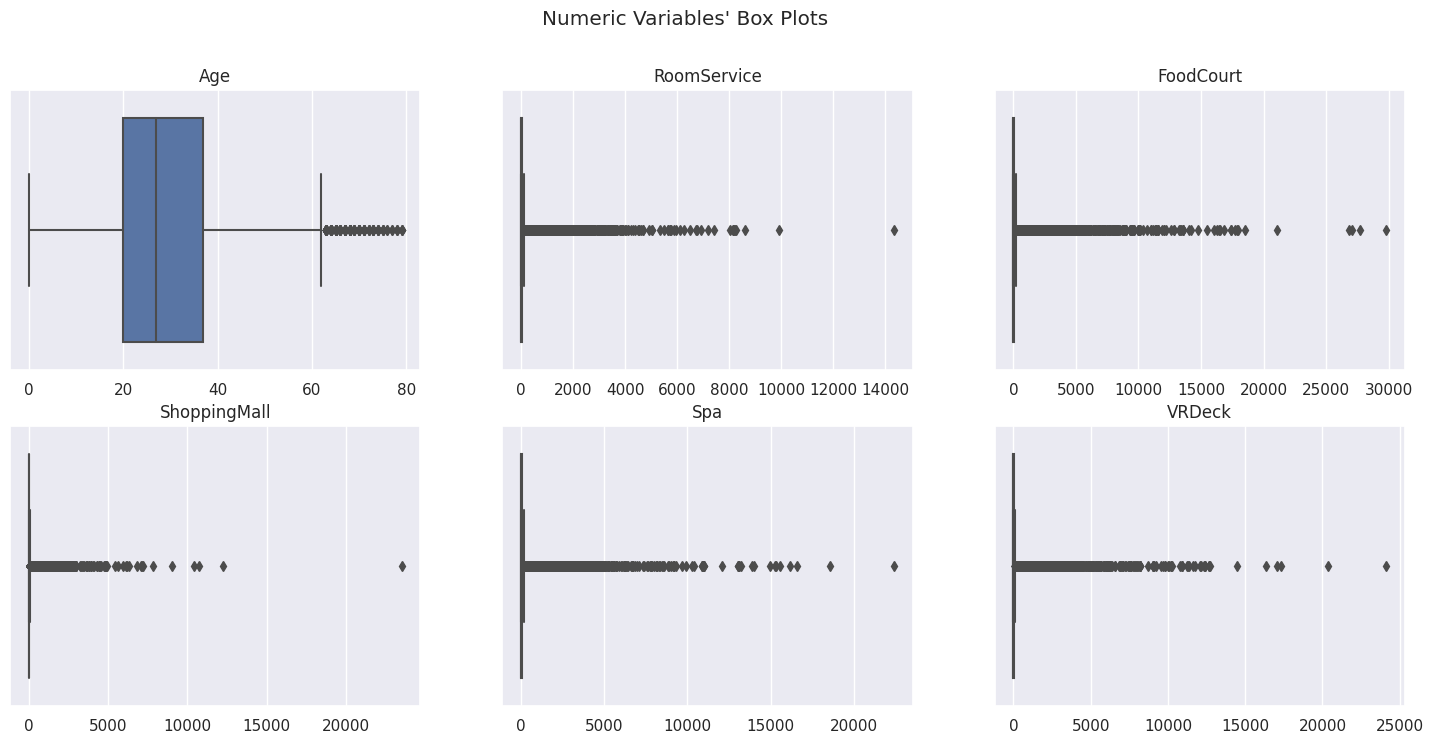

In [ ]:
## Do you have any outliers?
## Yes:

plot_multiple_boxplots(titanic_df, titanic_metric_features)


In [ ]:
## Would it make sense to remove the outliers using the IQR method?
## Why / Why not?

titanic_iqr_filters = get_iqr_filters(titanic_df, titanic_metric_features)

titanic_iqr = remove_outliers(titanic_df, titanic_iqr_filters)

print("Too much data removed using IQR")

Percentage of data kept after removing outliers: 41.56
Too much data removed using IQR


In [ ]:
## Handle the outliers


In [ ]:
## Use manual filters
titanic_manual_filters = (
    (titanic_df['RoomService']<=8000)
    &
    (titanic_df['FoodCourt']<=20000)
    &
    (titanic_df['ShoppingMall']<=7500)
    &
    (titanic_df['Spa']<=11000)
    &
    (titanic_df['VRDeck']<=12000)
)

titanic_df_1 = remove_outliers(titanic_df, titanic_manual_filters)

titanic_df = titanic_df_1.copy()

Percentage of data kept after removing outliers: 99.41


In [ ]:
## Are any of the features redundant?
print("No pairs have very high correlation")

No pairs have very high correlation


In [ ]:
## Are any of the features not relevant?
print("We already removed Name, Cabin, PassengerID")

We already removed Name, Cabin, PassengerID


In [ ]:
## Do you need to perform scaling?
print("Yes, the features are in different scales")

Yes, the features are in different scales


In [ ]:
# Use MinMaxScaler to scale the data
titanic_minmax = titanic_df.copy()
titanic_scaler = MinMaxScaler()
titanic_scaled_feat = titanic_scaler.fit_transform(titanic_minmax[titanic_metric_features])
titanic_minmax[titanic_metric_features] = titanic_scaled_feat
titanic_minmax[titanic_metric_features]

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,0.493671,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.303797,0.014718,0.000487,0.003479,0.050018,0.003748
2,0.734177,0.005806,0.193496,0.000000,0.611789,0.004173
3,0.417722,0.000000,0.069423,0.051635,0.303298,0.016438
4,0.202532,0.040913,0.003788,0.021016,0.051476,0.000170
...,...,...,...,...,...,...
8688,0.518987,0.000000,0.368974,0.000000,0.149690,0.006303
8689,0.227848,0.000000,0.000000,0.000000,0.000000,0.000000
8690,0.329114,0.000000,0.000000,0.260543,0.000091,0.000000
8691,0.405063,0.000000,0.056761,0.000000,0.032161,0.275530


In [ ]:
## Do you need to transform the categorical features?
print("Yes we need to use Onehot Encoding")

Yes we need to use Onehot Encoding


In [ ]:
titanic_df_ohc, titanic_ohc = get_ohc_df(titanic_df, titanic_non_metric_features)


In [ ]:
titanic_df_ohc

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,VRDeck,Name,Transported,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True,Transported_True
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0.0,Maham Ofracculy,False,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,44.0,Juanna Vines,True,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,49.0,Altark Susent,False,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,193.0,Solam Susent,False,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,2.0,Willy Santantines,True,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,...,74.0,Gravior Noxnuther,False,1.0,0.0,0.0,0.0,0.0,1.0,0.0
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,...,0.0,Kurta Mondalley,False,0.0,0.0,1.0,1.0,0.0,0.0,0.0
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,...,0.0,Fayey Connon,True,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,...,3235.0,Celeon Hontichre,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
titanic_ohc_feats = titanic_ohc.get_feature_names_out().tolist()
titanic_ohc_feats

['HomePlanet_Europa',
 'HomePlanet_Mars',
 'CryoSleep_True',
 'Destination_PSO J318.5-22',
 'Destination_TRAPPIST-1e',
 'VIP_True',
 'Transported_True']

In [ ]:
## Have you fixed all the issues you identified in your dataset?
